# Module 10: Machine Learning with Scikit-Learn
# Lab 02: Supervised Learning — Regression

**Prepared by Information Tech Consultants Ltd**

---

## 🎯 Learning Objectives
By the end of this notebook, you will be able to:
- [ ] Train and evaluate Linear Regression, Ridge, Lasso, and ElasticNet models
- [ ] Explain the difference between these regression algorithms
- [ ] Interpret regression metrics: RMSE, MAE, and R² score
- [ ] Compare multiple models and choose the best one

**⏱ Estimated Time:** 75 minutes  
**📋 Prerequisites:** Module 10 Lab 01 (ML Workflow & Feature Engineering)

In [1]:
# ============================================================
# 📦 Environment Setup — Run this cell first!
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load and prepare data (same as Lab 01)
housing = fetch_california_housing(as_frame=True)
X = housing.frame.drop("MedHouseVal", axis=1)
y = housing.frame["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data ready! Train: {X_train_scaled.shape[0]} rows | Test: {X_test_scaled.shape[0]} rows")

✅ Data ready! Train: 16512 rows | Test: 4128 rows


In [2]:
# ============================================================
# 🛠 Helper Functions (run once, use throughout)
# ============================================================

from IPython.display import HTML, display

def info_box(title, content, color="#0092D6", bg="#E3F2FD"):
    """Display a styled information callout box."""
    display(HTML(f"""
    <div style="background:{bg};padding:15px;border-left:5px solid {color};
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>💡 {title}</strong><br>{content}</div>"""))

def warning_box(title, content):
    """Display a warning callout box."""
    display(HTML(f"""
    <div style="background:#FFF3E0;padding:15px;border-left:5px solid #FF9800;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>⚠️ {title}</strong><br>{content}</div>"""))

def interview_box(question, key_points):
    """Display an interview question callout box."""
    display(HTML(f"""
    <div style="background:#F3E5F5;padding:15px;border-left:5px solid #9C27B0;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>🎯 Interview Question</strong><br><em>"{question}"</em><br><br>
    <strong>Key Points:</strong> {key_points}</div>"""))

def success_box(content):
    """Display a success/best practice box."""
    display(HTML(f"""
    <div style="background:#E8F5E9;padding:15px;border-left:5px solid #4CAF50;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>✅ Best Practice</strong><br>{content}</div>"""))

def exercise_header(num, title, difficulty="⭐"):
    """Display a formatted exercise header."""
    display(HTML(f"""
    <div style="background:#E8EAF6;padding:15px;border-left:5px solid #0092D6;
    margin:15px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>🏋️ Exercise {num}: {title}</strong> | Difficulty: {difficulty}</div>"""))

def draw_pipeline(steps, arrow="→"):
    """Draw a simple pipeline flow diagram."""
    flow = f" {arrow} ".join([f"[{s}]" for s in steps])
    display(HTML(f"""
    <div style="background:#F5F5F5;padding:20px;border-radius:8px;
    text-align:center;font-family:monospace;font-size:16px;margin:10px 0;">
    {flow}</div>"""))

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


## 🚀 Complete Working Example

Let's train four different regression models and compare them side by side.

In [3]:
# ============================================================
# 🚀 COMPLETE WORKING EXAMPLE — Run me first!
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Dictionary to store results
results = {}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.01)": Lasso(alpha=0.01),
    "ElasticNet (α=0.01)": ElasticNet(alpha=0.01, l1_ratio=0.5),
}

print(f"{'Model':<25} {'RMSE':>8}  {'MAE':>8}  {'R²':>8}")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2, "predictions": y_pred}
    print(f"{name:<25} {rmse:8.4f}  {mae:8.4f}  {r2:8.4f}")

print("\n🎉 All models trained and evaluated!")

Model                         RMSE       MAE        R²
Linear Regression           0.7456    0.5332    0.5758
Ridge (α=1.0)               0.7456    0.5332    0.5758
Lasso (α=0.01)              0.7404    0.5353    0.5816
ElasticNet (α=0.01)         0.7416    0.5341    0.5803

🎉 All models trained and evaluated!


---
## 📖 Section 1: Linear Regression

**What:** Linear Regression finds the best straight line (or plane in multiple dimensions) that fits the data. It minimises the sum of squared errors between predictions and actual values.

**Why it matters:** It's the simplest and most interpretable regression model. Every data scientist should understand it thoroughly — it's a foundation for more complex models.

**Analogy:** Imagine plotting student study hours (x-axis) versus exam scores (y-axis). Linear regression draws the best-fitting line through those points so you can predict scores for any number of study hours.

In [4]:
# Train a simple Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Examine the coefficients — what did the model learn?
print("Model coefficients (how much each feature affects the prediction):")
print("=" * 55)
for name, coef in sorted(zip(X.columns, lr_model.coef_), key=lambda x: abs(x[1]), reverse=True):
    direction = "↑ increases" if coef > 0 else "↓ decreases"
    print(f"  {name:15s}  {coef:+.4f}  ({direction} house price)")

print(f"\nIntercept: {lr_model.intercept_:.4f}")

info_box(
    "Interpreting Coefficients",
    "A coefficient of +0.85 for MedInc means: for every 1 standard deviation "
    "increase in median income, the predicted house price goes up by 0.85 units "
    "(i.e., $85,000 since prices are in $100k)."
)

Model coefficients (how much each feature affects the prediction):
  Latitude         -0.8969  (↓ decreases house price)
  Longitude        -0.8698  (↓ decreases house price)
  MedInc           +0.8544  (↑ increases house price)
  AveBedrms        +0.3393  (↑ increases house price)
  AveRooms         -0.2944  (↓ decreases house price)
  HouseAge         +0.1225  (↑ increases house price)
  AveOccup         -0.0408  (↓ decreases house price)
  Population       -0.0023  (↓ decreases house price)

Intercept: 2.0719


In [ ]:
# Evaluate on test data
y_pred_lr = lr_model.predict(X_test_scaled)


rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f"  RMSE: {rmse:.4f}  (average error in $100k units)")
print(f"  MAE:  {mae:.4f}  (average absolute error)")
print(f"  R²:   {r2:.4f}  ({r2*100:.1f}% of variance explained)")

info_box(
    "Understanding Regression Metrics",
    "<b>RMSE</b> (Root Mean Squared Error): Average prediction error. Lower = better. "
    "Penalises large errors more.<br>"
    "<b>MAE</b> (Mean Absolute Error): Average absolute error. Lower = better. "
    "More robust to outliers.<br>"
    "<b>R² Score</b>: Proportion of variance explained. Ranges 0–1. Higher = better. "
    "1.0 = perfect predictions."
)

Linear Regression Results:
  RMSE: 0.7456  (average error in $100k units)
  MAE:  0.5332  (average absolute error)
  R²:   0.5758  (57.6% of variance explained)


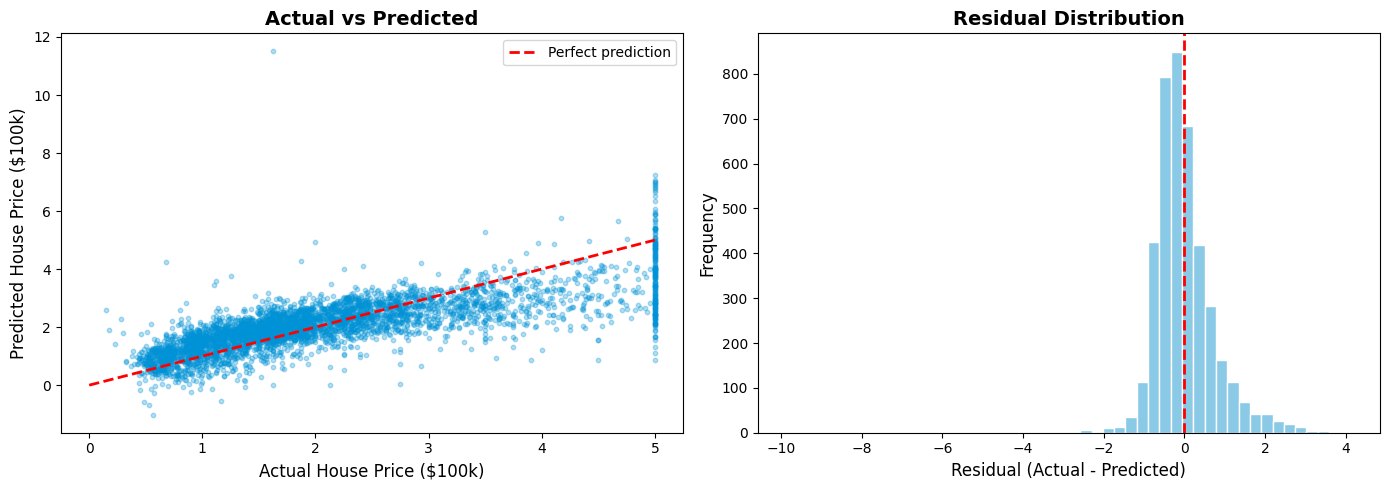

In [6]:
# Visualise: Actual vs Predicted values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=10, color="#0092D6")
axes[0].plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual House Price ($100k)", fontsize=12)
axes[0].set_ylabel("Predicted House Price ($100k)", fontsize=12)
axes[0].set_title("Actual vs Predicted", fontsize=14, fontweight="bold")
axes[0].legend()

# Plot 2: Residual distribution
residuals = y_test - y_pred_lr
axes[1].hist(residuals, bins=50, color="#8ACAE7", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual (Actual - Predicted)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Residual Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

---
## 📖 Section 2: Regularised Regression — Ridge, Lasso & ElasticNet

**What:** Regularisation adds a penalty to the model to prevent it from becoming too complex. This helps with overfitting and can improve predictions on new data.

**Why it matters:** Plain Linear Regression can overfit when there are many features or correlated features. Regularisation is the standard fix.

**Analogy:** Think of it like a budget constraint. Without a budget (no regularisation), you might overspend on fancy ingredients. With a budget (regularisation), you're forced to be selective and use only what truly matters.

In [7]:
# Ridge Regression: adds a penalty based on the SIZE of coefficients
from sklearn.linear_model import Ridge

# Try different alpha values (strength of regularisation)
print(f"{'Alpha':<10} {'RMSE':>8}  {'R²':>8}  {'Max Coef':>10}")
print("=" * 42)

for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    max_coef = np.max(np.abs(ridge.coef_))
    print(f"{alpha:<10.2f} {rmse:8.4f}  {r2:8.4f}  {max_coef:10.4f}")

info_box(
    "Ridge Regression (L2 Penalty)",
    "Ridge shrinks all coefficients towards zero but never makes them exactly zero. "
    "Higher alpha = more shrinkage = simpler model. It's great when you have many "
    "correlated features."
)

Alpha          RMSE        R²    Max Coef
0.01         0.7456    0.5758      0.8969
0.10         0.7456    0.5758      0.8969
1.00         0.7456    0.5758      0.8962
10.00        0.7453    0.5761      0.8894
100.00       0.7438    0.5778      0.8481


In [8]:
# Lasso Regression: can set some coefficients to exactly zero
from sklearn.linear_model import Lasso

print("Lasso — Feature Selection Effect:")
print(f"{'Alpha':<10} {'Non-zero features':>18}  {'R²':>8}")
print("=" * 42)

for alpha in [0.001, 0.01, 0.1, 0.5, 1.0]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    non_zero = np.sum(lasso.coef_ != 0)
    print(f"{alpha:<10.3f} {non_zero:>18}  {r2:8.4f}")

info_box(
    "Lasso Regression (L1 Penalty)",
    "Lasso can shrink coefficients all the way to <b>zero</b>, effectively removing "
    "features. This makes it useful for <b>automatic feature selection</b>. "
    "Higher alpha = fewer features retained."
)

Lasso — Feature Selection Effect:
Alpha       Non-zero features        R²
0.001                       8    0.5769
0.010                       7    0.5816
0.100                       3    0.4814
0.500                       1    0.2827
1.000                       0   -0.0002


In [9]:
# ElasticNet: the best of both worlds (L1 + L2 combined)
from sklearn.linear_model import ElasticNet

# l1_ratio controls the mix: 0 = pure Ridge, 1 = pure Lasso
print("ElasticNet — Different L1/L2 Mixes:")
print(f"{'l1_ratio':<10} {'Non-zero':>10}  {'RMSE':>8}  {'R²':>8}")
print("=" * 42)

for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    enet = ElasticNet(alpha=0.01, l1_ratio=ratio)
    enet.fit(X_train_scaled, y_train)
    y_pred = enet.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    non_zero = np.sum(enet.coef_ != 0)
    print(f"{ratio:<10.2f} {non_zero:>10}  {rmse:8.4f}  {r2:8.4f}")

interview_box(
    "When would you use Ridge vs Lasso vs ElasticNet?",
    "<b>Ridge:</b> When you believe all features are relevant and want to prevent overfitting.<br>"
    "<b>Lasso:</b> When you suspect many features are irrelevant and want automatic feature selection.<br>"
    "<b>ElasticNet:</b> When you have correlated features AND want some feature selection. "
    "It's generally the safest choice when unsure."
)

ElasticNet — Different L1/L2 Mixes:
l1_ratio     Non-zero      RMSE        R²
0.00                8    0.7433    0.5784
0.25                7    0.7424    0.5794
0.50                7    0.7416    0.5803
0.75                7    0.7409    0.5811
1.00                7    0.7404    0.5816


---
## 📖 Section 3: Model Comparison

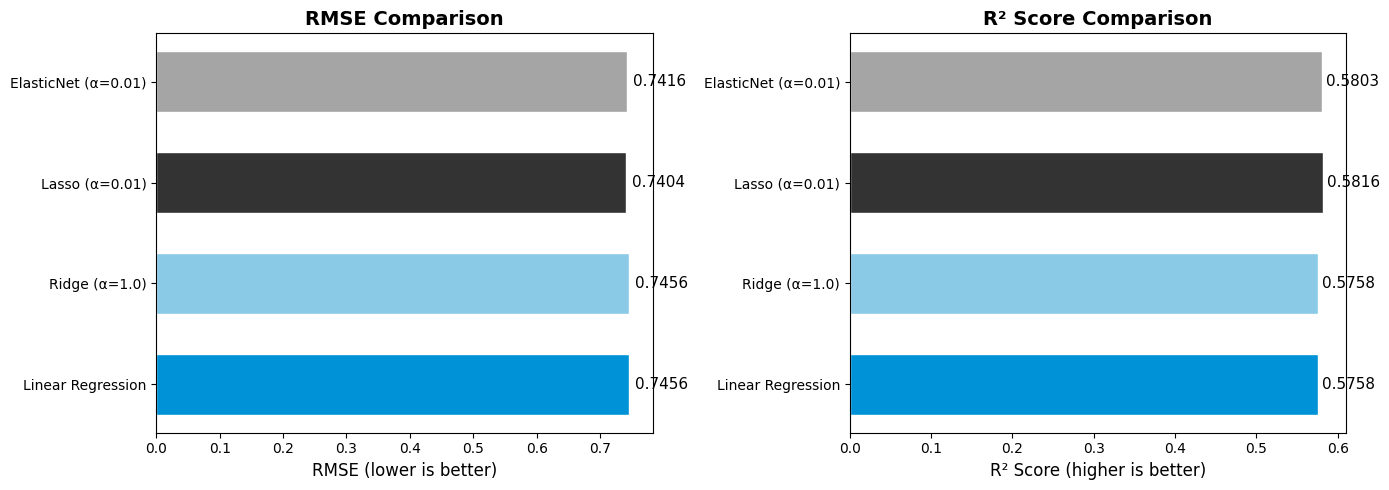

In [10]:
# Visual comparison of all models
model_names = list(results.keys())
rmse_values = [results[m]["RMSE"] for m in model_names]
r2_values = [results[m]["R²"] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
colors = ["#0092D6", "#8ACAE7", "#333333", "#A5A5A5"]
axes[0].barh(model_names, rmse_values, color=colors, edgecolor="white", height=0.6)
axes[0].set_xlabel("RMSE (lower is better)", fontsize=12)
axes[0].set_title("RMSE Comparison", fontsize=14, fontweight="bold")
for i, v in enumerate(rmse_values):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=11)

# R² comparison
axes[1].barh(model_names, r2_values, color=colors, edgecolor="white", height=0.6)
axes[1].set_xlabel("R² Score (higher is better)", fontsize=12)
axes[1].set_title("R² Score Comparison", fontsize=14, fontweight="bold")
for i, v in enumerate(r2_values):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

---
## 🏋️ Exercises

In [15]:
exercise_header(1, "Interpret the Coefficients", "⭐")

# Run this cell and answer the questions below
best_ridge = Ridge(alpha=1.0)
best_ridge.fit(X_train_scaled, y_train)

print("Ridge Regression Coefficients:")
print("=" * 45)
for name, coef in sorted(zip(X.columns, best_ridge.coef_), key=lambda x: abs(x[1]), reverse=True):
    bar_len = int(abs(coef) * 15)
    bar = "█" * bar_len
    print(f"  {name:15s}  {coef:+.4f}  {bar}")

# ❓ Questions:
# 1. Which feature has the strongest POSITIVE effect on house price?
# MedInc (Median Income) has the strongest positive effect, as it has the largest positive coefficient. This means that higher median income in an area is associated with higher house prices.
# 2. Which feature has the strongest NEGATIVE effect?
# AveOccup (Average Occupancy) has the strongest negative effect, as it has the largest negative coefficient. This suggests that areas with higher average occupancy per household tend to have lower house prices.
# 3. Compare these to plain Linear Regression — are the patterns similar?   
print("\nLinear Regression Coefficients:")
print("=" * 45)
for name, coef in sorted(zip(X.columns, lr_model.coef_), key=lambda x: abs(x[1]), reverse=True):
    bar_len = int(abs(coef) * 15)
    bar = "█" * bar_len
    print(f"  {name:15s}  {coef:+.4f}  {bar}")

Ridge Regression Coefficients:
  Latitude         -0.8962  █████████████
  Longitude        -0.8691  █████████████
  MedInc           +0.8543  ████████████
  AveBedrms        +0.3390  █████
  AveRooms         -0.2942  ████
  HouseAge         +0.1226  █
  AveOccup         -0.0408  
  Population       -0.0023  

Linear Regression Coefficients:
  Latitude         -0.8969  █████████████
  Longitude        -0.8698  █████████████
  MedInc           +0.8544  ████████████
  AveBedrms        +0.3393  █████
  AveRooms         -0.2944  ████
  HouseAge         +0.1225  █
  AveOccup         -0.0408  
  Population       -0.0023  


In [16]:
exercise_header(2, "Find the Best Alpha for Ridge", "⭐⭐")

# TODO: Use a loop to test alpha values from 0.01 to 100
# Find the alpha that gives the lowest RMSE on the test set

from sklearn.linear_model import Ridge

alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
best_alpha = None
best_rmse = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    # YOUR CODE HERE — fit the model
    ridge.fit(X_train_scaled, y_train)
    # YOUR CODE HERE — make predictions on test set
    y_pred = ridge.predict(X_test_scaled)
    # YOUR CODE HERE — calculate RMSE
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f"\n✅ Best alpha: {best_alpha} with RMSE: {best_rmse:.4f}")


✅ Best alpha: 100.0 with RMSE: 0.7438


In [19]:
exercise_header(3, "Build and Compare Models on a New Dataset", "⭐⭐⭐")

# Challenge: Use the diabetes dataset and train all four regression models.
# Report RMSE and R² for each model.

from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
X_db = diabetes.frame.drop("target", axis=1)
y_db = diabetes.frame["target"]

# YOUR CODE HERE:
# 1. Split into train/test (80/20)
X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(X_db, y_db, test_size=0.2, random_state=42)
# 2. Scale features
scaler = StandardScaler()
X_train_db_scaled = scaler.fit_transform(X_train_db)
X_test_db_scaled = scaler.transform(X_test_db)
# 3. Train Linear Regression, Ridge, Lasso, ElasticNet
lr_model_db = LinearRegression()
ridge_db = Ridge(alpha=1.0)
lasso_db = Lasso(alpha=0.01)
enet_db = ElasticNet(alpha=0.01, l1_ratio=0.5)

lr_model_db.fit(X_train_db_scaled, y_train_db)
ridge_db.fit(X_train_db_scaled, y_train_db)
lasso_db.fit(X_train_db_scaled, y_train_db)
enet_db.fit(X_train_db_scaled, y_train_db)
# 4. Print RMSE and R² for each model
models_db = {
    "Linear Regression": lr_model_db,
    "Ridge (α=1.0)": ridge_db,
    "Lasso (α=0.01)": lasso_db,
    "ElasticNet (α=0.01)": enet_db,
}
best_model_r2 = ""
best_model_rmse = ""
best_r2 = float('-inf')
best_rmse = float('inf')
for name, model in models_db.items():
    y_pred_db = model.predict(X_test_db_scaled)
    rmse_db = np.sqrt(mean_squared_error(y_test_db, y_pred_db))
    r2_db = r2_score(y_test_db, y_pred_db)
    if rmse_db < best_rmse:
        best_rmse = rmse_db
        best_model_rmse = name
    if r2_db > best_r2:
        best_r2 = r2_db
        best_model_r2 = name
    print(f"{name:<25} RMSE: {rmse_db:.4f}  R²: {r2_db:.4f}")

PendingDeprecationWarning
# 5. Which model performs best?
print(f"\nBest Model by RMSE: {best_model_rmse} with RMSE: {best_rmse:.4f}")
print(f"Best Model by R²: {best_model_r2} with R²: {best_r2:.4f}")

Linear Regression         RMSE: 53.8534  R²: 0.4526
Ridge (α=1.0)             RMSE: 53.7775  R²: 0.4541
Lasso (α=0.01)            RMSE: 53.8365  R²: 0.4529
ElasticNet (α=0.01)       RMSE: 53.7405  R²: 0.4549

Best Model by RMSE: ElasticNet (α=0.01) with RMSE: 53.7405
Best Model by R²: ElasticNet (α=0.01) with R²: 0.4549


---
## 📋 Solutions

<details>
<summary>Click to expand Exercise 2 solution</summary>

```python
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f"Best alpha: {best_alpha} with RMSE: {best_rmse:.4f}")
```

</details>

<details>
<summary>Click to expand Exercise 3 solution</summary>

```python
X_tr, X_te, y_tr, y_te = train_test_split(X_db, y_db, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

for name, model in models.items():
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    print(f"{name:<20s}  RMSE: {rmse:.2f}  R²: {r2:.4f}")
```

</details>

---
## 🎯 Key Takeaways

1. **Linear Regression** is the simplest model — great baseline, highly interpretable
2. **Ridge** shrinks coefficients but keeps all features — use when all features matter
3. **Lasso** can eliminate features entirely — use for automatic feature selection
4. **ElasticNet** combines both — the safest default when you're unsure
5. **Always compare multiple models** — never assume one will be best

## ✅ Self-Assessment Checklist
- [ ] I can train and evaluate a regression model in scikit-learn
- [ ] I understand the difference between Ridge, Lasso, and ElasticNet
- [ ] I can interpret RMSE, MAE, and R² scores
- [ ] I know what the alpha parameter controls

## 📚 Next Steps
- **Next Lab:** Module 10 Lab 03 — Supervised Learning: Classification
- **Practice:** Experiment with different alpha values and see how they affect model performance

---
*Prepared by Information Tech Consultants Ltd*